# 30 April 2026
- notebook to compare raw numbers of CV populations
- comparing Scaringi 1kpc pop from earth to thiele gxy DWD 
- questions
    - how many DWDs are in 150 pc / space density comparions
    - occupation fraction argument: how many CVs vs DWDs are in each LISA freq bin

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # LSS to avoid OOM errors when using jax in this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp
import sys
sys.path.append('../scripts/')
import paths
import h5py
import astropy.coordinates as apyco

- load populations (thiele+21 resampled to MW galactic positions)

In [2]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/resampled_keepnearby_McMillan_galaxy_Thiele_fiducial_Z.hdf'
dwdrsamp = pd.read_hdf(file)

In [3]:
dwdrsamp.columns

Index(['bin_num', 'mass_1', 'mass_2', 'kstar_1', 'kstar_2', 'sep', 'met',
       'tphys', 'rad_1', 'rad_2', 'xGx', 'yGx', 'zGx', 'FIRE_index', 'f_gw',
       'dist_sun', 'i'],
      dtype='object')

In [4]:
dwdco = apyco.SkyCoord(dwdrsamp['xGx'].to_numpy()*u.kpc, dwdrsamp['yGx'].to_numpy()*u.kpc, dwdrsamp['zGx'].to_numpy()*u.kpc, frame='galactocentric', representation_type='cartesian')

In [5]:
np.sum(dwdrsamp['dist_sun'] < 1)

np.int64(22115)

In [6]:
dwdSSBc = dwdco.transform_to(apyco.BarycentricMeanEcliptic)

In [7]:
np.allclose(dwdSSBc.distance.value, dwdrsamp['dist_sun'].to_numpy(), atol=1e-4)

True

In [33]:
cvgxyfile = paths.lssdata / 'CV_fullgxy/rseed81_thin/dat_fullgxy_thin_rs81_final.txt'
cvgxy = pd.read_csv(cvgxyfile)

In [34]:
cvgxy

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],Scar_reassigned,Pala_reassigned,dist_from_sun[kpc]
0,0.699585,0.661795,0.000092,0.868805,-1.659226,-1.864869,-0.140838,0.0,0.0,6.728370
1,0.698573,0.117336,0.000318,1.439806,-9.424070,-3.630087,-0.300962,0.0,0.0,3.869950
2,0.699477,0.144947,0.000287,1.007588,-4.359547,-0.921463,0.066491,0.0,0.0,3.873891
3,0.699896,0.086134,0.000380,1.208875,2.567456,3.155828,-0.640511,0.0,0.0,11.165146
4,0.700273,0.154995,0.000274,0.702665,0.424594,1.151216,-0.123345,0.0,0.0,8.624958
...,...,...,...,...,...,...,...,...,...,...
2372478,0.700239,0.245238,0.000157,1.056038,3.587964,-4.590419,-0.136123,0.0,0.0,12.578521
2372479,0.698801,0.040127,0.000432,1.259748,6.133003,-5.298820,0.554436,0.0,0.0,15.217313
2372480,0.699345,0.059323,0.000386,0.281418,8.249350,-2.209371,-0.050842,0.0,0.0,16.519888
2372481,0.698251,0.039373,0.000418,0.574314,-5.460642,-4.494527,0.079346,0.0,0.0,5.223685


In [35]:
cvco = apyco.SkyCoord(cvgxy[' x_galcent[kpc]'].to_numpy()*u.kpc, cvgxy[' y_galcent[kpc]'].to_numpy()*u.kpc, cvgxy[' z_galcent[kpc]'].to_numpy()*u.kpc, frame='galactocentric', representation_type='cartesian')
cvSSBc = cvco.transform_to(apyco.BarycentricMeanEcliptic)

In [36]:
np.allclose(cvSSBc.distance.value, cvgxy[' dist_from_sun[kpc]'].to_numpy(), atol=1)

True

In [37]:
cvdistdif = cvgxy[' dist_from_sun[kpc]'] - cvSSBc.distance.value

In [38]:
cvgxy[' dist_from_sun[kpc]']

0           6.728370
1           3.869950
2           3.873891
3          11.165146
4           8.624958
             ...    
2372478    12.578521
2372479    15.217313
2372480    16.519888
2372481     5.223685
2372482    10.231958
Name:  dist_from_sun[kpc], Length: 2372483, dtype: float64

In [39]:
cvdistdif[np.where(np.abs(cvdistdif) < 1e-2)[0]]

0         -2.159783e-11
1          3.116174e-12
2         -4.508660e-11
3          6.261303e-11
4         -4.012790e-11
               ...     
2372478    3.020695e-11
2372479    1.013056e-11
2372480   -1.290701e-11
2372481   -1.789147e-11
2372482    1.730349e-11
Name:  dist_from_sun[kpc], Length: 2372483, dtype: float64

(2372483,)


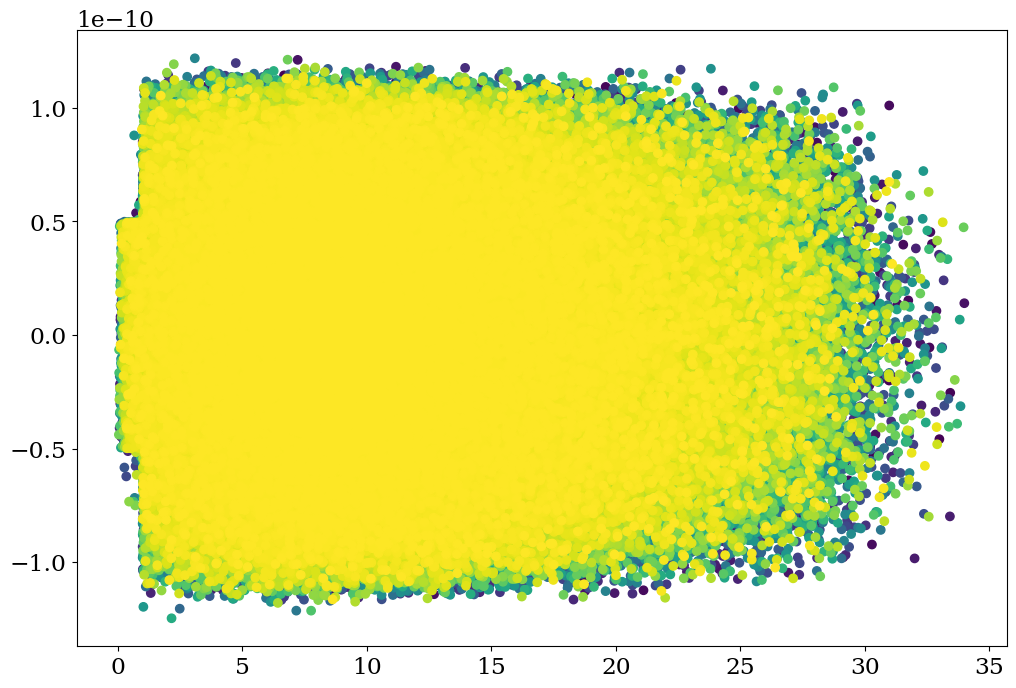

In [40]:
normcol = np.arange(cvdistdif.shape[0])
print(normcol.shape)
plt.scatter(cvSSBc.distance.value, cvdistdif, c=normcol)

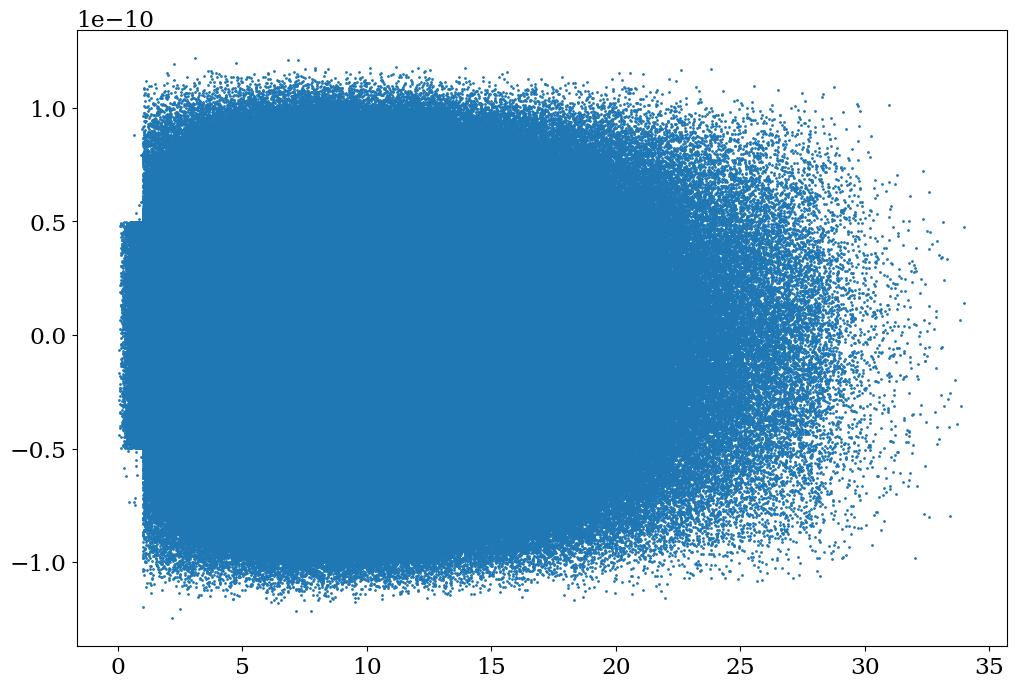

In [41]:
plt.plot(cvSSBc.distance.value, cvdistdif, 'o', markersize=1)

(array([7.1600e+02, 2.7360e+03, 4.9980e+03, 7.1310e+03, 9.5740e+03,
        1.1999e+04, 1.4587e+04, 1.6815e+04, 1.9904e+04, 2.3000e+04,
        2.6351e+04, 3.0269e+04, 3.4187e+04, 3.8074e+04, 4.2314e+04,
        4.7733e+04, 5.2891e+04, 5.8403e+04, 6.3552e+04, 7.0487e+04,
        7.6242e+04, 8.2810e+04, 8.8144e+04, 9.2562e+04, 9.3921e+04,
        9.2528e+04, 8.8790e+04, 8.5436e+04, 8.1783e+04, 7.7209e+04,
        7.2971e+04, 6.8844e+04, 6.3705e+04, 5.9689e+04, 5.5946e+04,
        5.1855e+04, 4.8118e+04, 4.4272e+04, 4.1146e+04, 3.7507e+04,
        3.5051e+04, 3.2111e+04, 2.9300e+04, 2.6863e+04, 2.4797e+04,
        2.3067e+04, 2.0871e+04, 1.9052e+04, 1.7308e+04, 1.5800e+04,
        1.4448e+04, 1.3434e+04, 1.1882e+04, 1.0897e+04, 1.0127e+04,
        9.0660e+03, 8.1530e+03, 7.5090e+03, 6.7820e+03, 6.1000e+03,
        5.3780e+03, 5.0040e+03, 4.4940e+03, 3.9690e+03, 3.5400e+03,
        3.2160e+03, 2.9220e+03, 2.5490e+03, 2.3550e+03, 2.0020e+03,
        1.8380e+03, 1.6790e+03, 1.4850e+03, 1.38

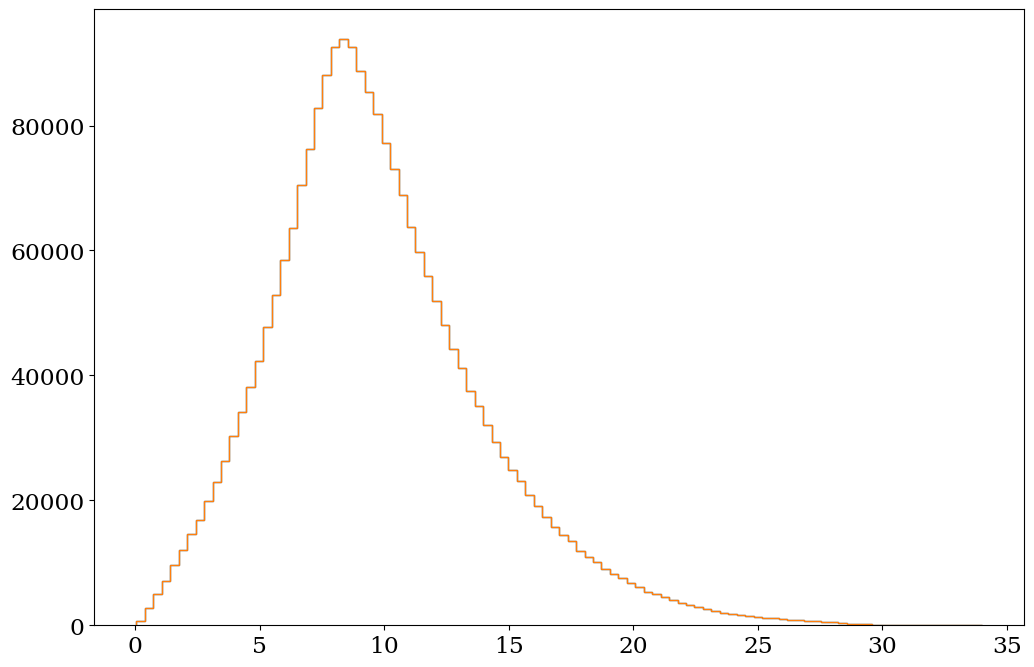

In [42]:
plt.hist(cvSSBc.distance.value, bins=100, histtype='step')
plt.hist(cvgxy[' dist_from_sun[kpc]'], bins=100, histtype='step')

In [7]:
galcentdef = apyco.galactocentric_frame_defaults.get_from_registry('latest')
galcent_sun_dist = galcentdef['parameters']['galcen_distance'].to('kpc').value
galcent_z_sun = galcentdef['parameters']['z_sun'].to('kpc').value

CVdistsun = np.sqrt((cvgxy[' x_galcent[kpc]'] + galcent_sun_dist)**2 + cvgxy[' y_galcent[kpc]']**2 + (cvgxy[' z_galcent[kpc]'] - galcent_z_sun)**2)

(array([6.56400e+03, 1.59260e+04, 2.08840e+04, 3.07220e+04, 4.19130e+04,
        5.47820e+04, 6.99910e+04, 8.76590e+04, 1.08235e+05, 1.31061e+05,
        1.55435e+05, 1.76479e+05, 1.82440e+05, 1.71819e+05, 1.56973e+05,
        1.40447e+05, 1.23802e+05, 1.07028e+05, 9.19830e+04, 7.85300e+04,
        6.67370e+04, 5.68980e+04, 4.70760e+04, 3.65520e+04, 3.09190e+04,
        2.77340e+04, 2.32800e+04, 1.88500e+04, 1.57710e+04, 1.28900e+04,
        1.05420e+04, 8.47100e+03, 6.90500e+03, 5.54300e+03, 4.52800e+03,
        3.67500e+03, 2.95800e+03, 2.34100e+03, 1.93000e+03, 1.56500e+03,
        1.21400e+03, 8.97000e+02, 5.22000e+02, 2.90000e+02, 1.89000e+02,
        1.07000e+02, 6.90000e+01, 5.70000e+01, 2.20000e+01, 1.30000e+01]),
 array([ 0.0364248 ,  0.71257877,  1.38873274,  2.06488671,  2.74104068,
         3.41719465,  4.09334862,  4.76950259,  5.44565656,  6.12181053,
         6.7979645 ,  7.47411847,  8.15027244,  8.82642641,  9.50258038,
        10.17873435, 10.85488832, 11.53104229, 12

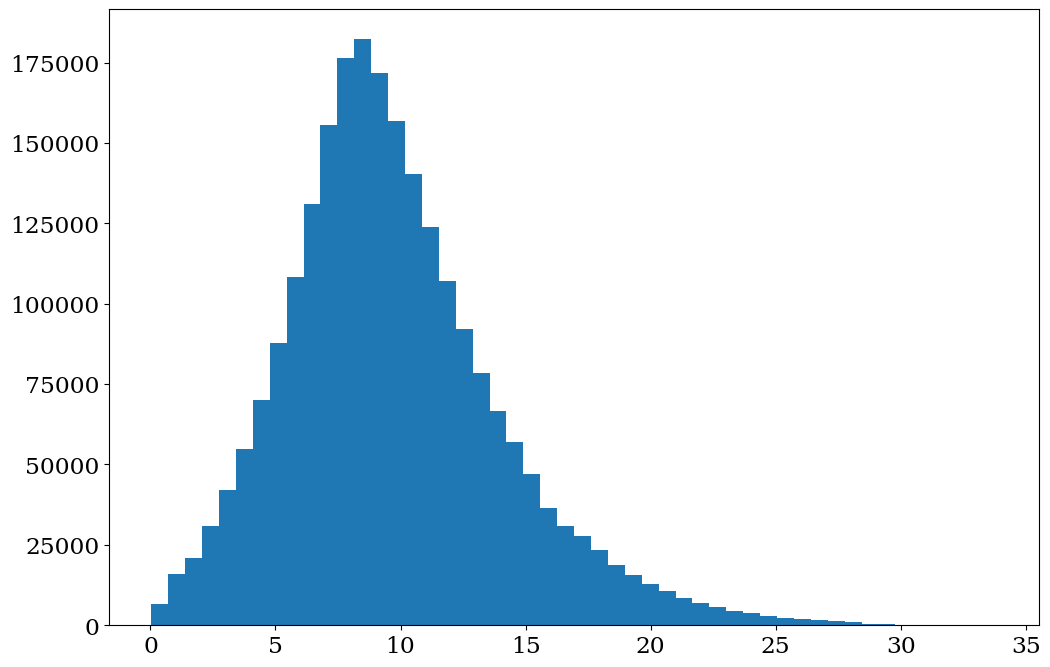

In [8]:
plt.hist(CVdistsun, bins=50)

In [43]:
print(np.min(CVdistsun))
print(np.sum(CVdistsun < 1))

NameError: name 'CVdistsun' is not defined

In [44]:
np.sum(cvgxy[' dist_from_sun[kpc]'] < 1)

np.int64(7352)

In [45]:
cvgxy.shape[0] / dwdrsamp.shape[0]

0.199954067124366

In [46]:
7284/np.sum(dwdrsamp['dist_sun'] < 1)

np.float64(0.3293692064209812)

In [47]:
np.sum(cvgxy[' dist_from_sun[kpc]'] < 1)/np.sum(dwdrsamp['dist_sun'] < 1)

np.float64(0.332444042505087)

In [48]:
kpcsph = (4/3)*np.pi*(1*u.kpc)**3
kpccyl = np.pi*(1*u.kpc)**2*2*u.kpc